In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse

from pathlib import Path

from graph_transformer_long_range_niches.pp import sliding_window, split_adata, identify_shh_center
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
LEGNINI23 = "/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad"

# Load data

Figure 3.f,h

In [3]:
adata = sc.read_h5ad(LEGNINI23)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [ ]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [8]:
# adata.obsm['spatial'] = adata.obsm['coordinates']
# del adata.obsm['coordinates']

In [ ]:
np.isnan(adata.obsm["spatial"]).sum()

Remove all cells that have entry NaN in .obsm['coordinates'].
If NaN is in .obsm it leads to error when creating graph. 

In [ ]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

Make sure that obs_names are unique and convertable to string. 

In [ ]:
adata.obs_names_make_unique

In [9]:
adata.obs['obs_names'] = adata.obs_names

In [21]:
adata.obs_names = np.array(range(adata.n_obs)).astype(str)

In [22]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '43752', '43753', '43754', '43755', '43756', '43757', '43758', '43759',
       '43760', '43761'],
      dtype='object', length=43762)

In [23]:
#adata.write(LEGNINI23)

In [4]:
adata.obs_names = adata.obs_names.str.replace('-', '', regex=False)

In [5]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '43752', '43753', '43754', '43755', '43756', '43757', '43758', '43759',
       '43760', '43761'],
      dtype='object', length=43762)

In [6]:
shh_slides = ['slide4_A2-1', 'slide4_B2-2']

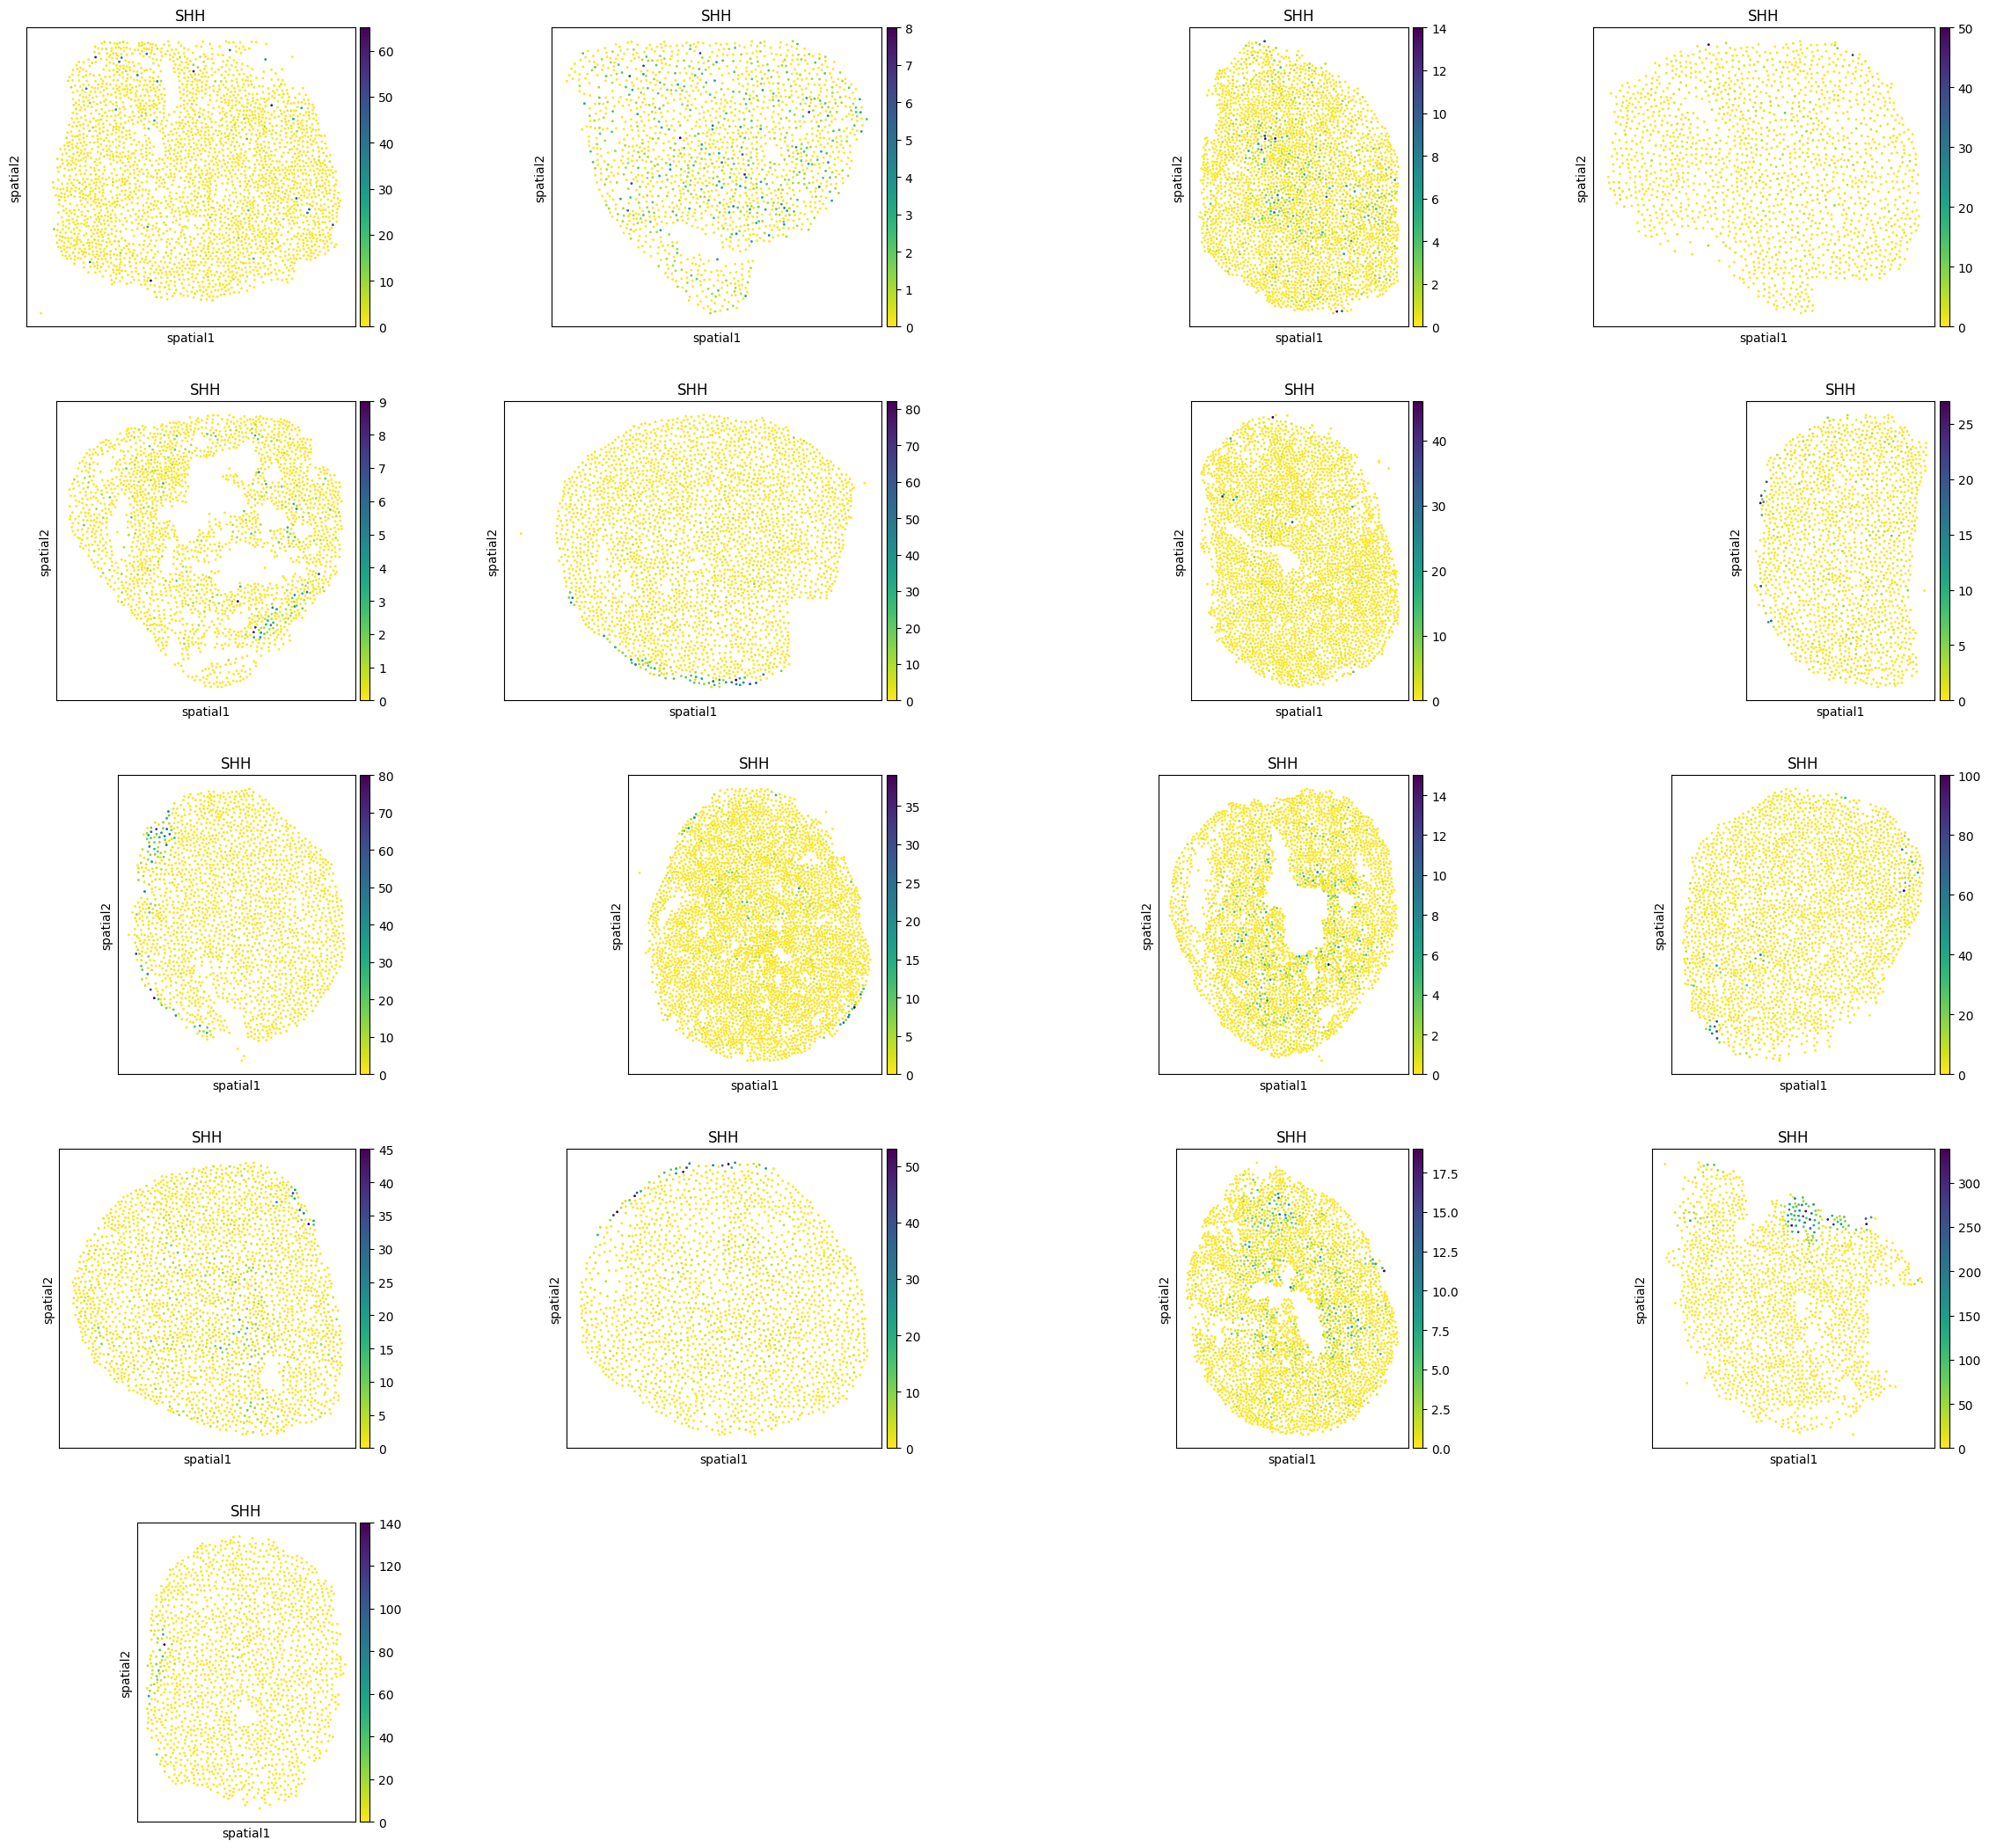

In [9]:
sq.pl.spatial_scatter(
        adata,
        library_key = 'sample',
        #library_id = shh_slides,
        color = ['SHH'],
        cmap = 'viridis_r',
        shape= None,
        save = f'{FIG_PATH}/legnini23/legnini23_log1p_SHH.jpeg'
)

In [28]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['sample', 'condition', 'organoid']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

sample       condition  organoid   
slide1_D2-2  SHH        organoid #2    4318
slide1_D2-3  SHH        organoid #4    3621
slide1_C2-2  SHH        organoid #2    3510
slide4_B2-1  SHH        organoid #2    3345
slide1_B2-1  SHH        organoid #2    3299
slide1_A2-1  SHH        organoid #2    3023
slide1_C2-1  Ctrl       organoid #5    2870
slide4_A2-1  SHH        organoid #2    2630
slide4_A2-2  SHH        organoid #1    2506
slide1_B2-3  SHH        organoid #4    2241
slide4_A2-3  Ctrl       organoid #5    1984
slide1_C2-5  Ctrl       organoid #8    1958
slide4_B2-2  SHH        organoid #3    1779
slide1_B2-2  Ctrl       organoid #6    1701
slide1_A2-2  SHH        organoid #4    1694
slide4_B2-3  Ctrl       organoid #7    1643
slide1_C2-3  Ctrl       organoid #7    1640
Name: count, dtype: int64


In [24]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names'
    uns: 'condition_colors'
    obsm: 'spatial'

### Check cross-gene vs cross-cell similarity

Calculate cosine-similarity cross-gene and cross-cell. 

- Which genes exhibit the highest and lowest cosine similarity across cells?
- 

In [35]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

def compute_gene_expression_variability(adata, condition=None):
    """
    Compute gene expression variability across cells and across genes.
    
    Parameters:
    - adata: AnnData object containing the spatial transcriptomics data.
    - condition: str or None. If provided, subsets the analysis to the specified condition in adata.obs['condition'].
    
    Returns:
    - Dictionary with mean variances and most/least variable genes.
    """
    
    # Ensure the data is dense if it's sparse
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
    gene_names = adata.var_names if hasattr(adata, "var_names") else np.arange(X.shape[1])
    
    # Subset data if condition is specified
    if condition:
        if condition not in adata.obs.columns:
            raise ValueError(f"The column {condition} is not present in adata.obs.")
        conditions = adata.obs[condition].unique()

    results = {}

    for cond_var in conditions:
        print(f"\n### Analyzing Condition: {condition} ###")
        
        # Subset data
        condition_mask = adata.obs[condition] == cond_var
        print(condition_mask)
        X_cond = X[condition_mask,:]
        # Compute variance across genes per cell
        var_genes_per_cell = np.var(X_cond, axis=1)
    
        # Compute variance across cells per gene
        var_cells_per_gene = np.var(X_cond, axis=0)
    
        # Create DataFrame for gene variability
        var_df = pd.DataFrame({"Gene": gene_names, "Variance_across_cells": var_cells_per_gene})
        var_df = var_df.sort_values(by="Variance_across_cells", ascending=False)
    
        # Identify most and least variable genes
        most_variable_genes = var_df.head(10)
        least_variable_genes = var_df.tail(10)
    
        # Store results
        results[cond_var] = {
            "mean_var_genes": np.mean(var_genes_per_cell),
            "mean_var_cells": np.mean(var_cells_per_gene),
            "most_variable_genes": most_variable_genes,
            "least_variable_genes": least_variable_genes
        }
    
        # Print results
        print("\nMost variable genes across cells:")
        print(most_variable_genes)
        
        print("\nLeast variable genes across cells:")
        print(least_variable_genes)
    
        print(f"\nMean variance across genes (per cell): {results[cond_var]['mean_var_genes']:.3f}")
        print(f"Mean variance across cells (per gene): {results[cond_var]['mean_var_cells']:.3f}")
    
        # Plot distributions
        plt.figure(figsize=(8, 5))
        sns.kdeplot(var_genes_per_cell, label="Var across genes (per cell)", fill=True)
        sns.kdeplot(var_cells_per_gene, label="Var across cells (per gene)", fill=True)
        plt.legend()
        plt.xlabel("Variance")
        plt.title(f"Variance Distributions {'for ' + cond_var if condition else '(Full Dataset)'}")
        plt.show()
        
    return results


### Analyzing Condition: condition ###
0         True
1         True
2         True
3         True
4         True
         ...  
43757    False
43758    False
43759    False
43760    False
43761    False
Name: condition, Length: 43762, dtype: bool

Most variable genes across cells:
          Gene  Variance_across_cells
78       STMN2             768.899597
82       TUBB3             461.395599
13   Circ.CDR1             399.116425
55      NKX6.1             317.556152
46        MAP2             222.943130
14   Circ.RMST             158.957199
77        SOX2             110.650055
0   AC129492.1             105.936394
41         JUN              91.162910
71      PTPRZ1              85.141228

Least variable genes across cells:
      Gene  Variance_across_cells
10    CDR1               0.171745
6     ARG1               0.124595
8     BMP4               0.034989
50   MYRIP               0.032702
9    CALB1               0.029360
7   BCL11B               0.018223
37    HOPX              

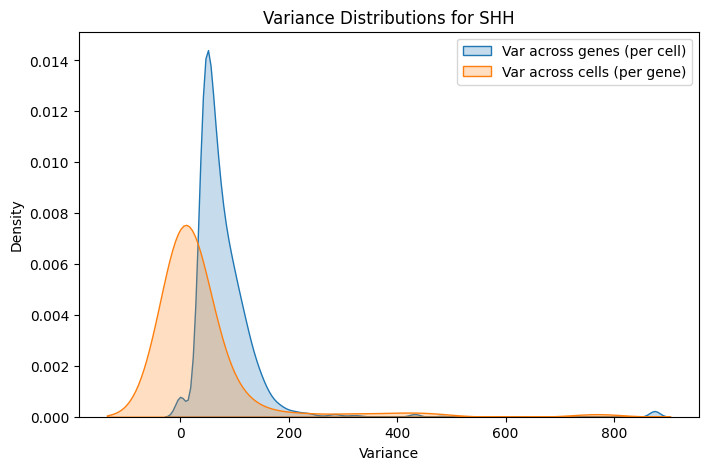


### Analyzing Condition: condition ###
0        False
1        False
2        False
3        False
4        False
         ...  
43757     True
43758     True
43759     True
43760     True
43761     True
Name: condition, Length: 43762, dtype: bool

Most variable genes across cells:
         Gene  Variance_across_cells
82      TUBB3             346.724762
14  Circ.RMST             293.035950
13  Circ.CDR1             276.643250
78      STMN2             201.268845
46       MAP2             152.384476
41        JUN             106.771042
26      FOXA2              95.580299
71     PTPRZ1              66.914375
39       IRX3              63.931015
77       SOX2              63.276070

Least variable genes across cells:
      Gene  Variance_across_cells
37    HOPX               0.017125
4     AQP4               0.013002
45     LUM               0.007221
6     ARG1               0.006956
10    CDR1               0.005567
86   FOXG1               0.002578
80    TBR1               0.001824
7

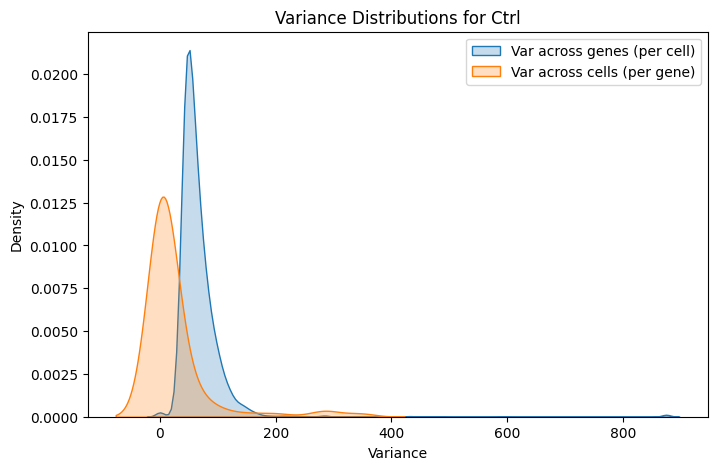

{'SHH': {'mean_var_genes': 82.141266,
  'mean_var_cells': 40.759537,
  'most_variable_genes':           Gene  Variance_across_cells
  78       STMN2             768.899597
  82       TUBB3             461.395599
  13   Circ.CDR1             399.116425
  55      NKX6.1             317.556152
  46        MAP2             222.943130
  14   Circ.RMST             158.957199
  77        SOX2             110.650055
  0   AC129492.1             105.936394
  41         JUN              91.162910
  71      PTPRZ1              85.141228,
  'least_variable_genes':       Gene  Variance_across_cells
  10    CDR1               0.171745
  6     ARG1               0.124595
  8     BMP4               0.034989
  50   MYRIP               0.032702
  9    CALB1               0.029360
  7   BCL11B               0.018223
  37    HOPX               0.017170
  80    TBR1               0.015457
  53  NKX2.1               0.007819
  87   TREM2               0.000276},
 'Ctrl': {'mean_var_genes': 66.88846,
  'mean

In [36]:
compute_gene_expression_variability(adata, condition='condition')

# Preprocessing for InterScale

1. **Sliding windows**: If there are samples with more than 2k cells then we split the samples into sliding windows.
2. **Radius selection**: Find the radius for which the samples / windows have an average of 30 neighbors. 

In [5]:
sq.gr.spatial_neighbors(
    adata,
    radius=150,
    coord_type=spatial_neigbors_kwargs.coord_type,
    library_key = spatial_neigbors_kwargs.library_key
)

NameError: name 'spatial_neigbors_kwargs' is not defined

In [ ]:
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

In [ ]:
sq.gr.spatial_neighbors(
    adata,
    radius=200,
    coord_type=spatial_neigbors_kwargs.coord_type,
    library_key = spatial_neigbors_kwargs.library_key
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_key = spatial_neigbors_kwargs.library_key,
    library_id = ['slide1_A2-1', 'slide4_A2-3'],
    connectivity_key="spatial_connectivities",
    img=False,
    na_color="lightgrey",
    size=10,
    shape = None,
)

In [ ]:
conn = adata.obsp['spatial_connectivities']
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

## SHH pathway genes

According to publication the induction was best achieved in: in organoids 2 and 3 (e.g. slide 4 A2-1 and slide 4 B2-2 are shown in the associated publication).

In [ ]:
pathway_genes = ['FOXA2', 'FOXG1', 'NKX2.1', 'NKX6.2', 'OLIG2']
upregulated_genes = ['FOXA1', 'FOXA2']
downregulated_genes = ['DBX2', 'DBX1']

In [ ]:
adata.X = adata.layers['log1p_norm']

In [ ]:
gex_shh = adata[:, 'SHH'].X

shh_threshold = 0.7 works well for sample = 'slide1_A2-1'

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_key = 'sample',
    library_id = ['slide1_A2-1', 'slide4_B2-2'],
    color =  ['shh_cluster'],
    shape= None,
    size = 8, 
)

In [ ]:
sub_adata = adata[adata.obs['sample'].isin(['slide1_A2-1', 'slide4_B2-2'])]

In [ ]:
np.unique(sub_adata.obs["shh_cluster"])

In [51]:
sq.tl.var_by_distance(
    adata=sub_adata,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/tl/_var_by_distance.py:65: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[design_matrix_key] = _add_metadata(


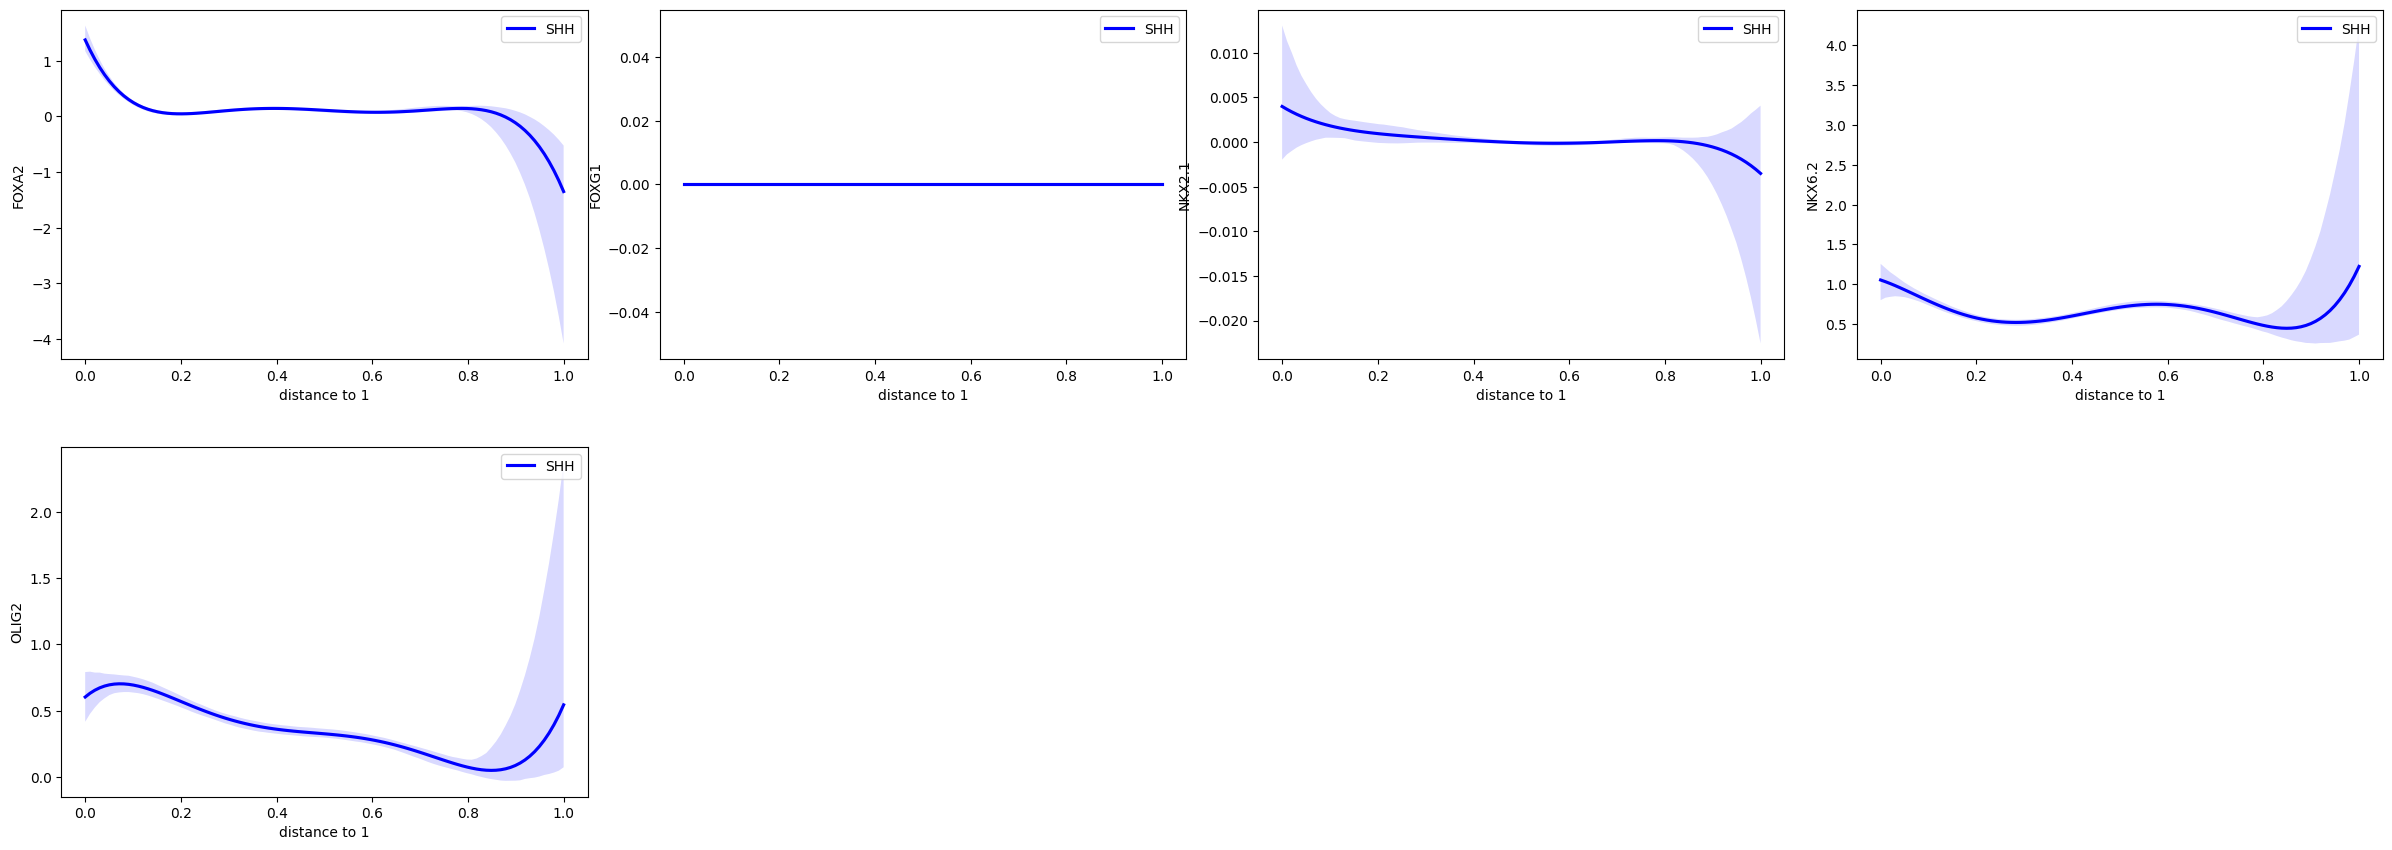

In [52]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=pathway_genes,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

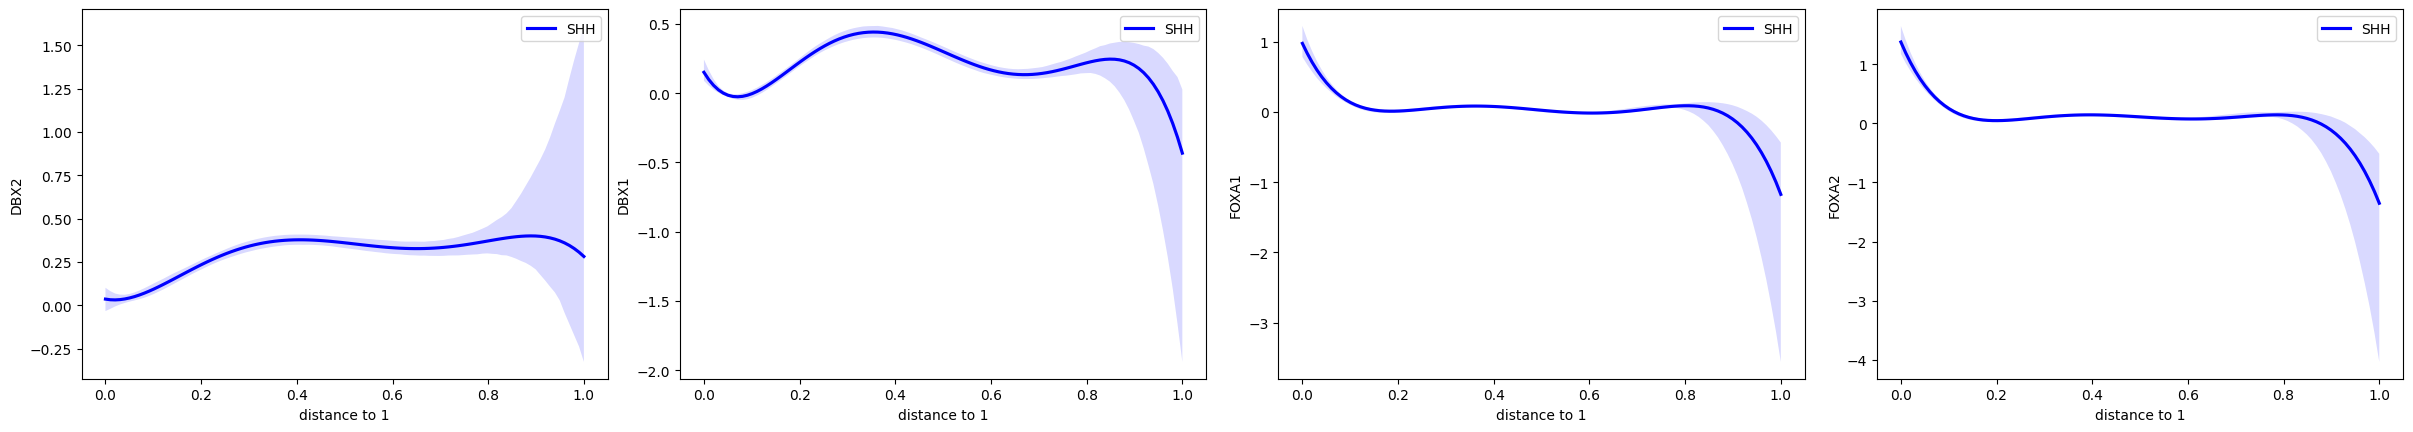

In [53]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=downregulated_genes + upregulated_genes,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

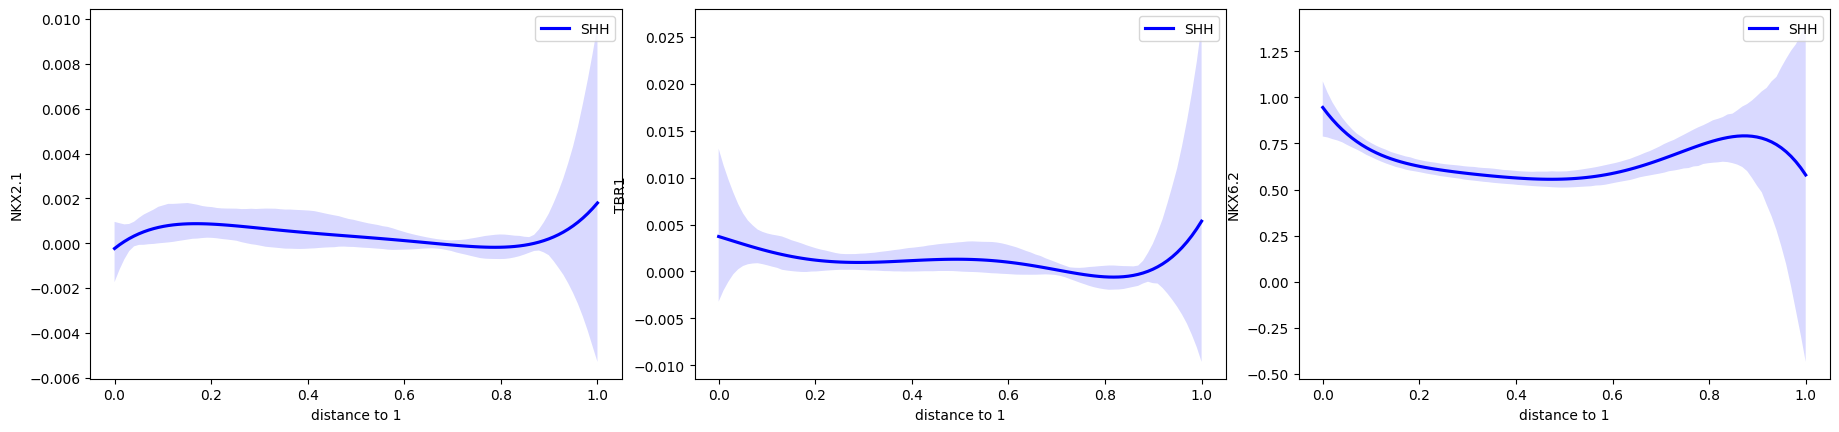

In [45]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=['NKX2.1', 'TBR1', 'NKX6.2'],
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

In [51]:
global_embedding = ['NKX2.1', 'TBR1', 'NKX6.2', 'OLIG1', 'EYA4']
local_embedding = ['KLF13', 'CUX2', 'ARG1', 'SATB2', 'MNX1']

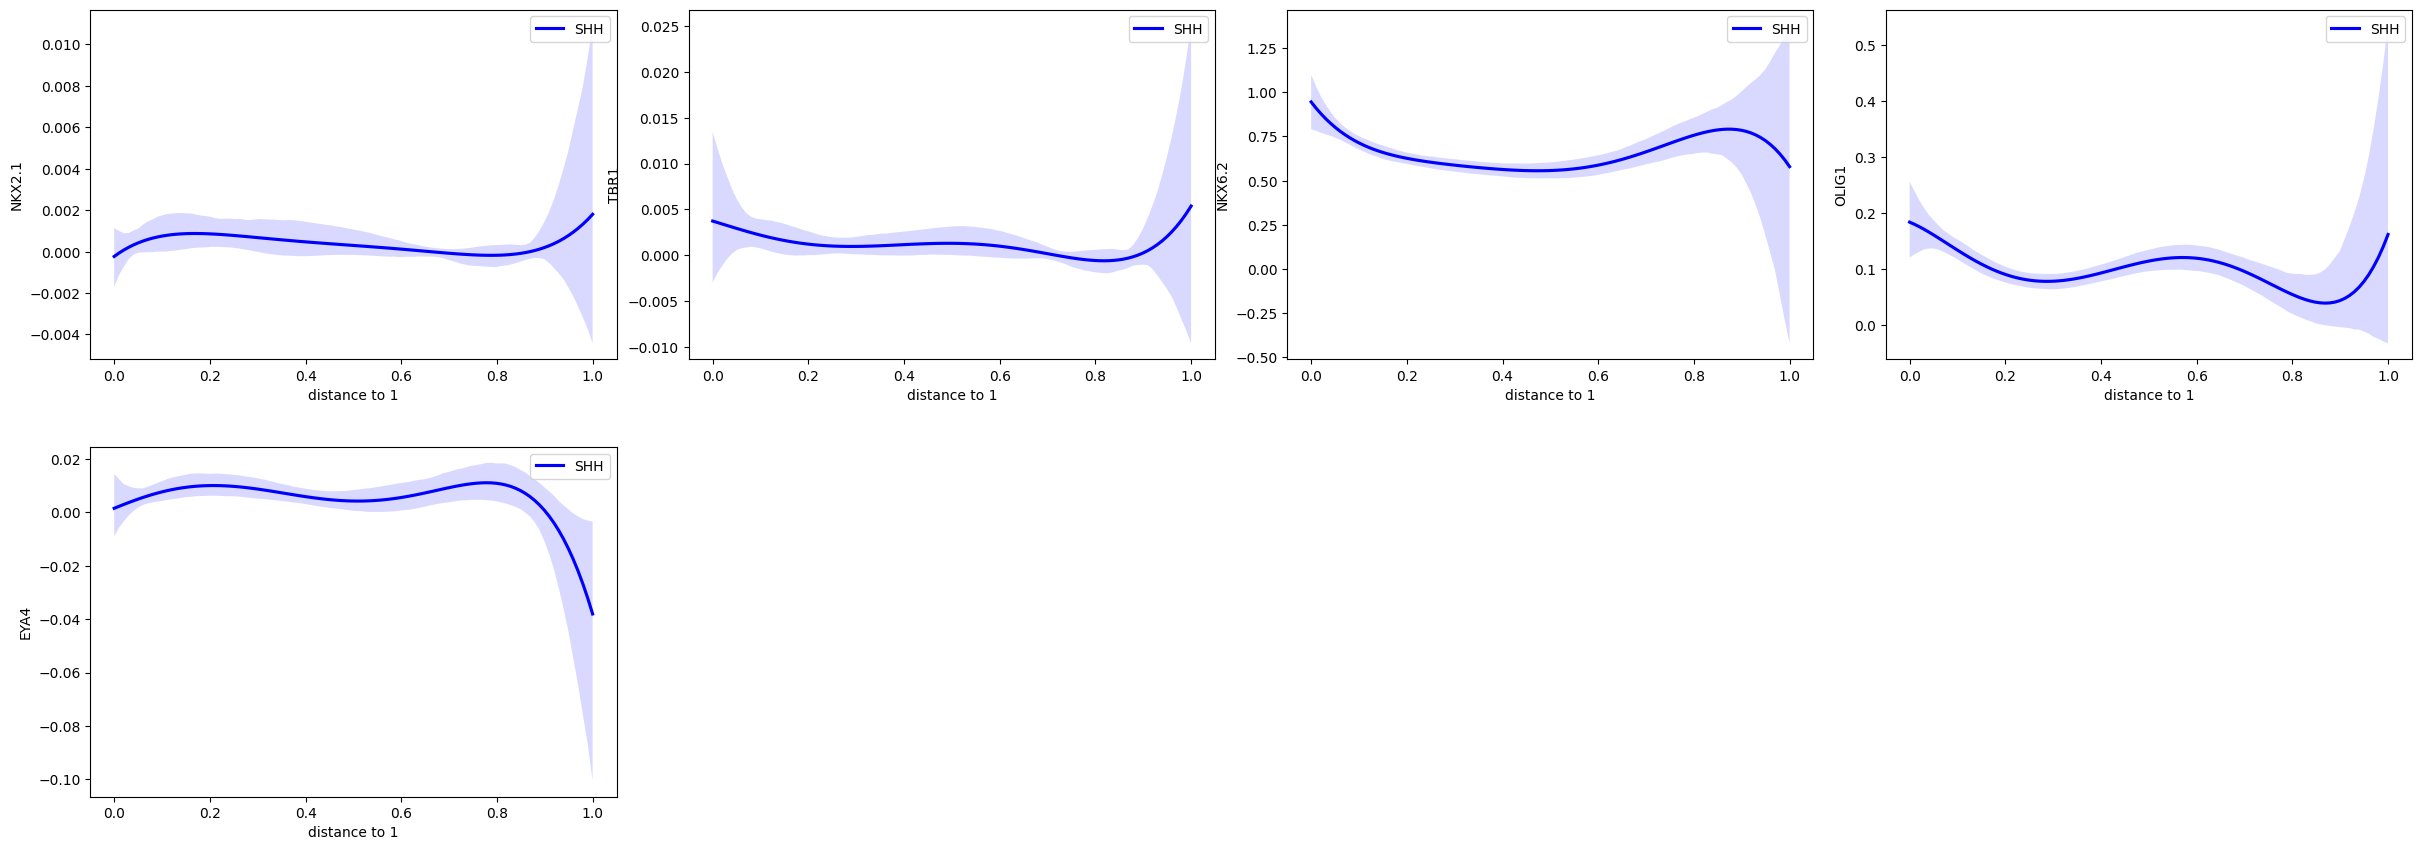

In [52]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=global_embedding,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)

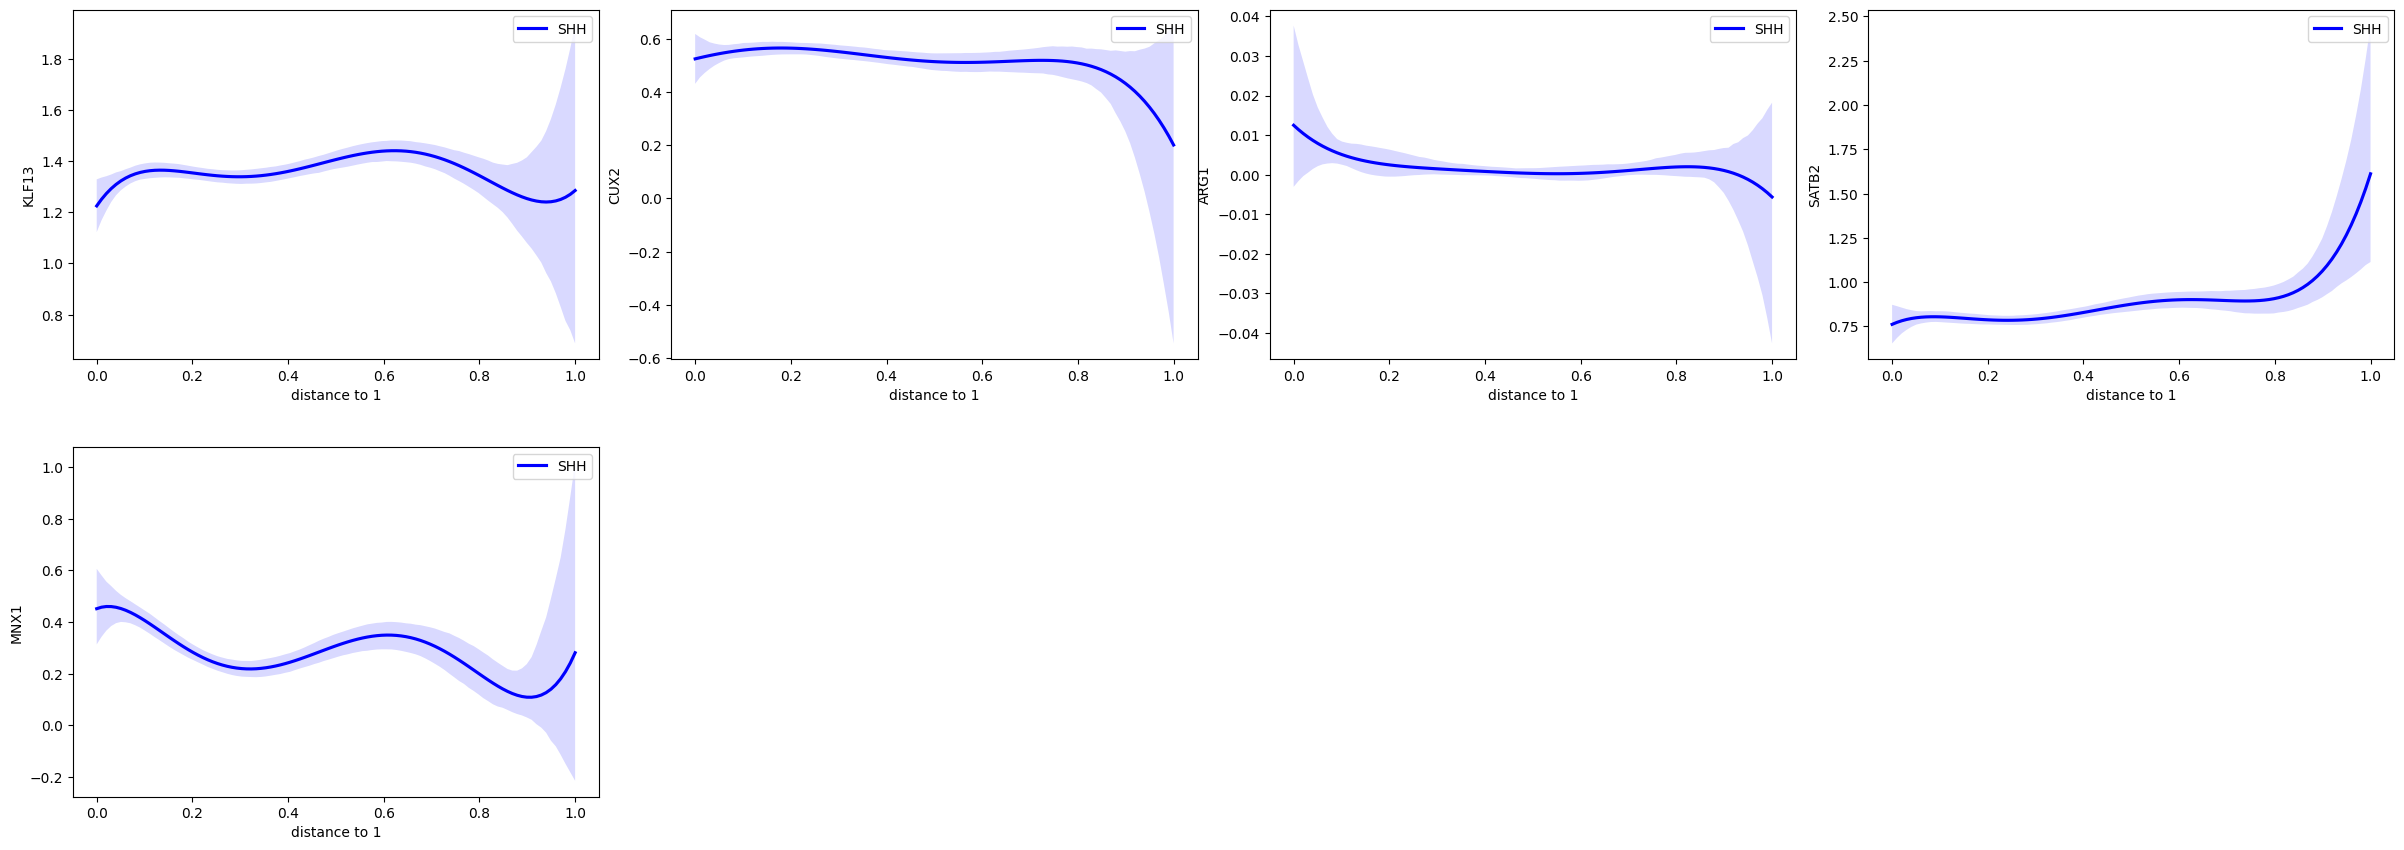

In [53]:
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=local_embedding,
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=False,
    figsize=(6, 4),
)